In [1]:
import ipympl
%matplotlib ipympl

In [2]:
# setting up logging first or else it gets preempted by another package
import watershed_workflow.ui
watershed_workflow.ui.setup_logging(1)

In [3]:
## Importing all the package needed to run the watershed workflow
# conda package imports
import os,sys
import logging
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm as pcm
import shapely
import pandas as pd
import geopandas as gpd
import cftime, datetime
pd.options.display.max_columns = None
import pickle

sys.path.append('/Users/s2t/softwares/seacas/lib')

import watershed_workflow 
import watershed_workflow.config
import watershed_workflow.sources
import watershed_workflow.utils
import watershed_workflow.plot
import watershed_workflow.mesh
import watershed_workflow.regions
import watershed_workflow.meteorology
import watershed_workflow.land_cover_properties
import watershed_workflow.resampling
import watershed_workflow.condition
import watershed_workflow.io
import watershed_workflow.sources.standard_names as names

watershed_workflow.ui.setup_logging(1,None)




sys.path.append('/Users/s2t/softwares/ats_input_spec')
 

%set_env AMANZI_SRC_DIR=/Users/s2t/softwares/ats/repos/amanzi
%set_env ATS_SRC_DIR=/Users/s2t/softwares/ats/repos/amanzi/src/physics/ats
sys.path.append('/Users/s2t/softwares/ats/repos/amanzi/tools/amanzi_xml')




# ats_input_spec library, to be moved to amanzi_xml
import ats_input_spec
import ats_input_spec.public
import ats_input_spec.io

# amanzi_xml, included in AMANZI_SRC_DIR/tools/amanzi_xml
import amanzi_xml.utils.io as aio
import amanzi_xml.utils.search as asearch
import amanzi_xml.utils.errors as aerrors

env: AMANZI_SRC_DIR=/Users/s2t/softwares/ats/repos/amanzi
env: ATS_SRC_DIR=/Users/s2t/softwares/ats/repos/amanzi/src/physics/ats


## Input: Parameters and other source data

In [4]:
# Force Watershed Workflow to pull data from this directory rather than a shared data directory.
# This picks up the Coweeta-specific datasets set up here to avoid large file downloads for 
# demonstration purposes.
#
def splitPathFull(path):
    """
    Splits an absolute path into a list of components such that
    os.path.join(*splitPathFull(path)) == path
    """
    parts = []
    while True:
        head, tail = os.path.split(path)
        if head == path:  # root on Unix or drive letter with backslash on Windows (e.g., C:\)
            parts.insert(0, head)
            break
        elif tail == path:  # just a single file or directory
            parts.insert(0, tail)
            break
        else:
            parts.insert(0, tail)
            path = head
    return parts

cwd = splitPathFull(os.getcwd())
assert cwd[-1] == 'Neches_new'
cwd = cwd[:-1]

# Note, this directory is where downloaded data will be put as well
data_dir = os.path.join(*(cwd + ['input_data',]))
def toInput(filename):
    return os.path.join(data_dir, filename)

output_dir = os.path.join(*(cwd + ['output_data',]))
output_filenames = dict()
def fromOutput(filename):
    return os.path.join(output_dir, filename)    

def toOutput(role, filename):
    output_filenames[role] = filename
    return fromOutput(filename)

# check output and input dirs exist
if not os.path.isdir(data_dir):
    os.makedirs(data_dir, exist_ok=True)
if not os.path.isdir(output_dir):
    os.makedirs(output_dir, exist_ok=True)
       

In [5]:
# Set the data directory to the local space to get the locally downloaded files
watershed_workflow.config.setDataDirectory(data_dir)


In [6]:
## Parameters cell -- this provides all parameters that can be changed via pipelining to generate a new watershed. 
name = 'Neches_River'
hucs = ['1202'] # a list of HUCs to run
neches_shapefile = '/Users/s2t/research/neches/scripts/neches_boundary.shp'
#neches_shapefile = '/Users/s2t/research/neches/scripts/subbasins.shp'
#near_coastal = ('/Users/s2t/research/neches/data/near_coast_huc12s_nhdv2.shp')#

# Geometric parameters
# -- parameters to clean and reduce the river network prior to meshing
prune_by_area = 100              # km^2
simplify = 125                   # length scale to target average edge 

# -- mesh triangle refinement control
refine_d0 = 200
refine_d1 = 600

refine_L0 = 125
refine_L1 = 300

refine_A0 = refine_L0**2 / 2
refine_A1 = refine_L1**2 / 2

# Note that, by default, we tend to work in the DayMet CRS because this allows us to avoid
# reprojecting meteorological forcing datasets.
crs = watershed_workflow.crs.default_crs


In [7]:
# set up a dictionary of source objects
#
# Data sources, also called managers, deal with downloading and parsing data files from a variety of online APIs.
sources = watershed_workflow.sources.getDefaultSources()

# log the sources that will be used here
watershed_workflow.sources.logSources(sources)




2025-11-21 12:50:58,292 - root - INFO: Using sources:
2025-11-21 12:50:58,294 - root - INFO: --------------
2025-11-21 12:50:58,295 - root - INFO: HUC: WBD
2025-11-21 12:50:58,296 - root - INFO: hydrography: NHDPlus MR v2.1
2025-11-21 12:50:58,297 - root - INFO: DEM: 3DEP 60m
2025-11-21 12:50:58,297 - root - INFO: soil structure: National Resources Conservation Service Soil Survey (NRCS Soils)
2025-11-21 12:50:58,298 - root - INFO: geologic structure: shapefile: "GLHYMPS.shp"
2025-11-21 12:50:58,298 - root - INFO: land cover: NLCD 2021 L48
2025-11-21 12:50:58,299 - root - INFO: LAI: MODIS
2025-11-21 12:50:58,299 - root - INFO: depth to bedrock: raster: "average_soil_and_sedimentary-deposit_thickness.tif"
2025-11-21 12:50:58,300 - root - INFO: meteorology: AORC v1.1


In [8]:
neches_source = watershed_workflow.sources.ManagerShapefile(neches_shapefile, id_name='name')
neches = neches_source.getShapes(out_crs=crs)

2025-11-21 12:50:58,526 - root - INFO: fixing column: geometry


In [9]:
neches

,FID,geometry,ID,name
0,0,"POLYGON ((18974.998 1021965.049, 18852.987 102...",0,0


In [10]:
shp_path = "/Users/s2t/research/neches/scripts/outlets_with_subbasins.shp"

# load it as a GeoDataFrame
outlets = gpd.read_file(shp_path)

In [11]:
outlets

,outlet_ID,subbasin,comid,measure,geometry
0,1115825,Neches River,1115825.0,0.000000,POINT (579625.33 -1316883.087)
1,1114345,"Neches Rv Saltwater Barrier at Beaumont, TX",1114345.0,70.148240,POINT (557363.601 -1301256.708)
2,1111453,"Neches Rv nr Town Bluff, TX",1111453.0,36.536823,POINT (546790.75 -1231265.986)
3,1109655,"Neches Rv nr Rockland, TX",1109655.0,68.708029,POINT (520996.669 -1205983.191)
4,1079041,"Neches Rv nr Diboll, TX",1079041.0,14.809472,POINT (482154.327 -1197312.999)
5,1077643,"Neches Rv nr Alto, TX",1077643.0,88.308180,POINT (447877.552 -1152620.754)
6,1152351,"Angelina Rv nr Lufkin, TX",1152351.0,6.487554,POINT (487555.866 -1161833.619)
7,1150499,"Angelina Rv nr Alto, TX",1150499.0,25.782583,POINT (465265.719 -1141154.93)
8,4452936,"Neches Rv nr Neches, TX",4452936.0,88.308180,POINT (419405.031 -1121725.832)
9,1166409,"Village Ck nr Kountze, TX",1166409.0,36.536823,POINT (537961.037 -1275465.997)


In [12]:
neches['reach_ID'] = pd.Series([
    1115825, 1114345, 1111453, 1109655, 1079041, 1077643, 1152351,
    1150499, 4452936, 1166409, 1157813, 1143252, 1151409, 4451722,
    1149925, 1159329, 1080121, 1524153
])

In [13]:
outlets['outlet_ID'] = outlets['outlet_ID'].astype(int)

# Now create the mapping
id_to_geom = dict(zip(outlets['outlet_ID'], outlets['geometry']))

# Add the outlet geometry to neches
neches['outlet'] = neches['reach_ID'].map(id_to_geom)

In [14]:
neches

,FID,geometry,ID,name,reach_ID,outlet
0,0,"POLYGON ((18974.998 1021965.049, 18852.987 102...",0,0,1115825,POINT (579625.3302517189 -1316883.0871090333)


EPSG:5070


2025-11-21 12:50:59,301 - root - INFO: fixing column: geometry
2025-11-21 12:50:59,488 - root - INFO: Removing holes on 1 polygons
2025-11-21 12:50:59,489 - root - INFO:   -- removed interior
2025-11-21 12:50:59,490 - root - INFO:   -- union
2025-11-21 12:50:59,490 - root - INFO: Parsing 1 components for holes
2025-11-21 12:50:59,490 - root - INFO:   -- complete


EPSG:5070


<Axes: >

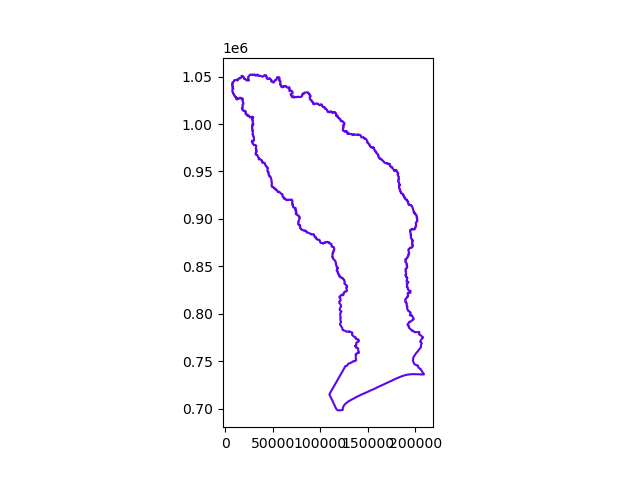

In [15]:
# get the shape and crs of the shape
print(crs)
watershed_shapes = sources['HUC'].getShapesByID(hucs, out_crs=crs)
print(watershed_shapes.crs)

watershed = watershed_workflow.split_hucs.SplitHUCs(neches)
watershed.plot()



## the Watershed

In [16]:
sources = watershed_workflow.sources.getDefaultSources()
sources['hydrography'] = watershed_workflow.sources.hydrography_sources['NHDPlus MR v2.1']

watershed_workflow.sources.logSources(sources)

2025-11-21 12:50:59,603 - root - INFO: Using sources:
2025-11-21 12:50:59,603 - root - INFO: --------------
2025-11-21 12:50:59,604 - root - INFO: HUC: WBD
2025-11-21 12:50:59,605 - root - INFO: hydrography: NHDPlus MR v2.1
2025-11-21 12:50:59,605 - root - INFO: DEM: 3DEP 60m
2025-11-21 12:50:59,606 - root - INFO: soil structure: National Resources Conservation Service Soil Survey (NRCS Soils)
2025-11-21 12:50:59,606 - root - INFO: geologic structure: shapefile: "GLHYMPS.shp"
2025-11-21 12:50:59,606 - root - INFO: land cover: NLCD 2021 L48
2025-11-21 12:50:59,606 - root - INFO: LAI: MODIS
2025-11-21 12:50:59,607 - root - INFO: depth to bedrock: raster: "average_soil_and_sedimentary-deposit_thickness.tif"
2025-11-21 12:50:59,607 - root - INFO: meteorology: AORC v1.1


## the Rivers 

In [17]:
# download/collect the river network within that shape's bounds
reaches = sources['hydrography'].getShapesByGeometry(watershed.df, out_crs=crs)

# remove coastlines
reaches = reaches[reaches.ftype != 'Coastline']
print(reaches.crs)

# construct rivers
rivers = watershed_workflow.river_tree.createRivers(reaches, method='hydroseq')
print(rivers[0].df.crs)

reaches

/Users/s2t/ATS_model/watershed-workflow/watershed_workflow/sources/manager_hyriver.py:111: UserWarning: 130 of 6222 requests failed.. IDs of the failed requests are ['1150531', '1147411', '1159721', '1143272', '1078597', '1111501', '1479451', '1114291', '1524297', '1523735', '1151961', '4454256', '1475649', '1111485', '1165137', '1477525', '4453258', '1166621', '1080167', '1147413', '1114327', '1524087', '1114177', '1114173', '1475703', '1159685', '1479705', '1114379', '1114209', '1479899', '1115797', '1479801', '1475205', '1111343', '1479737', '1118633', '1479863', '1114239', '1165133', '1160739', '1479439', '4453778', '1147229', '1479905', '1158961', '1475679', '1114149', '1111487', '1159697', '1114243', '1114235', '1523769', '1114421', '1114285', '1524107', '1114197', '1479359', '1479777', '1479769', '1523985', '1524067', '1114423', '1158105', '1524293', '1526161', '1475671', '1160743', '1479907', '1111341', '1114445', '1524065', '1151651', '1159731', '1114153', '1158103', '1114275'

EPSG:5070
EPSG:5070


,geometry,comid,fdate,resolution,gnis_id,reachcode,flowdir,wbareacomi,ftype,fcode,shape_length,streamleve,streamcalc,fromnode,tonode,levelpathi,pathlength,terminalpa,arbolatesu,startflag,terminalfl,dnlevel,uplevelpat,dnlevelpat,dnminorhyd,dndraincou,frommeas,tomeas,rtndiv,vpuin,vpuout,divdasqkm,tidal,totma,wbareatype,pathtimema,hwnodesqkm,maxelevraw,minelevraw,maxelevsmo,minelevsmo,slope,elevfixed,hwtype,slopelenkm,qa_ma,va_ma,qc_ma,vc_ma,qe_ma,ve_ma,qa_01,va_01,qc_01,vc_01,qe_01,ve_01,qa_02,va_02,qc_02,vc_02,qe_02,ve_02,qa_03,va_03,qc_03,vc_03,qe_03,ve_03,qa_04,va_04,qc_04,vc_04,qe_04,ve_04,qa_05,va_05,qc_05,vc_05,qe_05,ve_05,qa_06,va_06,qc_06,vc_06,qe_06,ve_06,qa_07,va_07,qc_07,vc_07,qe_07,ve_07,qa_08,va_08,qc_08,vc_08,qe_08,ve_08,qa_09,va_09,qc_09,vc_09,qe_09,ve_09,qa_10,va_10,qc_10,vc_10,qe_10,ve_10,qa_11,va_11,qc_11,vc_11,qe_11,ve_11,qa_12,va_12,qc_12,vc_12,qe_12,ve_12,lakefract,surfarea,rareahload,rpuid,vpuid,enabled,gridcode,featureid,sourcefc,shape_length_ca,shape_area,catchment_area,ID,name,length,stream_order,drainage_area_sqkm,catchment,hydroseq,uphydroseq,dnhydroseq,divergence
0,"LINESTRING (128525.31 892407.945, 128565.469 8...",101,2010-12-01T05:00:00Z,Medium,,12020002001025,With Digitized,0,StreamRiver,46000,0.031470,3,3,630000001.0,630000660.0,630004361.0,328.738,630002611.0,4278.117,0,0,3,630004361.0,630004361.0,0.0,1,0.00000,72.67003,0,0,0,157.0221,0,0.140432,,6.362768,NaN,-9998.0,3493.0,3695.0,3655.0,0.000123,0,,3.251,58.059,0.86013,88.057,0.87907,88.057,0.87907,143.042,1.19898,211.024,1.21609,211.024,1.21609,124.747,1.13656,198.769,1.18771,198.769,1.18771,108.320,1.07674,149.919,1.06540,149.919,1.06540,67.164,0.90451,111.723,0.95596,111.723,0.95596,54.661,0.84275,91.004,0.88913,91.004,0.88913,33.090,0.71773,82.962,0.86129,82.962,0.86129,18.064,0.60521,28.133,0.61974,28.133,0.61974,13.795,0.56562,18.383,0.55678,18.383,0.55678,14.016,0.56780,15.637,0.53633,15.637,0.53633,12.668,-9998,24.673,-9998,24.673,-9998,14.385,0.57140,24.396,0.59705,24.396,0.59705,94.773,1.02411,160.588,1.09355,160.588,1.09355,NaN,NaN,NaN,12a,12,1,1605970.0,101.0,NHDFlowline,0.100422,0.000432,4.5666,101,,3.251,3,7253.8209,"POLYGON ((130305.023 890715.004, 130259.066 89...",630004505.0,630004506.0,630004420.0,1
1,"LINESTRING (96000.55 939129.398, 95910.447 939...",1076713,1999-06-25T04:00:00Z,Medium,,12020002000449,With Digitized,0,StreamRiver,46003,0.031671,3,1,630047515.0,630000480.0,630047476.0,422.331,630002611.0,3.333,1,0,3,0.0,630047476.0,0.0,1,40.33927,100.00000,0,0,0,5.4783,0,0.159005,,8.639946,0.4617,9288.0,7903.0,9288.0,7903.0,0.004351,0,H,3.183,1.928,0.75653,5.463,0.79597,5.463,0.79597,4.584,1.01820,9.989,0.98016,9.989,0.98016,4.391,1.00217,11.046,1.01702,11.046,1.01702,3.833,0.95386,8.832,0.93765,8.832,0.93765,2.559,0.82923,5.915,0.81700,5.915,0.81700,1.653,0.72136,5.172,0.78201,5.172,0.78201,1.014,0.62697,4.150,0.72975,4.150,0.72975,0.521,0.53209,1.006,0.50693,1.006,0.50693,0.441,0.51314,0.683,0.47003,0.683,0.47003,0.441,0.51314,0.408,0.43134,0.408,0.43134,0.441,-9998,0.929,-9998,0.929,-9998,0.441,0.51314,0.497,0.44492,0.497,0.44492,2.880,0.86296,8.181,0.91258,8.181,0.91258,NaN,NaN,NaN,12a,12,1,1605568.0,1076713.0,NHDFlowline,0.100033,0.000520,5.4783,1076713,,3.333,1,5.4783,"POLYGON ((94484.973 937244.968, 94469.33 93759...",630068854.0,0.0,630047476.0,0
2,"LINESTRING (97179.95 939092.196, 97197.86 9390...",1076715,2008-06-13T04:00:00Z,Medium,1383546,12020002000252,With Digitized,0,StreamRiver,46003,0.029921,2,1,630047516.0,630000478.0,630021919.0,423.036,630002611.0,3.175,1,0,2,0.0,630021919.0,0.0,1,48.28816,100.00000,0,0,0,5.5512,0,0.150631,,8.665124,0.4905,9208.0,7848.0,9208.0,7848.0,0.004496,0,H,3.025,1.983,0.76078,5.590,0.80039,5.590,0.80039,4.733,1.02641,10.276,0.98818,10.276,0.98818,4.479,1.00568,11.237,1.02123,11.237,1.02123,3.938,0.95961,9.036,0.94331,9.036,0.94331,2.612,0.83205,6.024,0.82032,6.024,0.82032,1.712,0.72682,5.324,0.78782,5.324,0.78782,1.044,0.63017,4.257,0.73413,4.257,0.73413,0.540,0.53513,1.041,0.50993

In [18]:
watershed_orig, rivers_orig = watershed, rivers

In [19]:
watershed

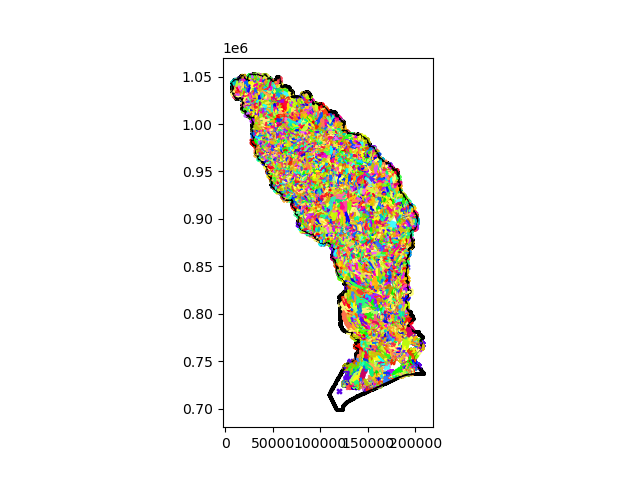

In [20]:
def plot(ws, rivs, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ws.plot(color='k', marker='+', markersize=10, ax=ax)
    for river in rivs:
        river.plot(marker='x', markersize=10, ax=ax)

    return ax

ax = plot(watershed, rivers)

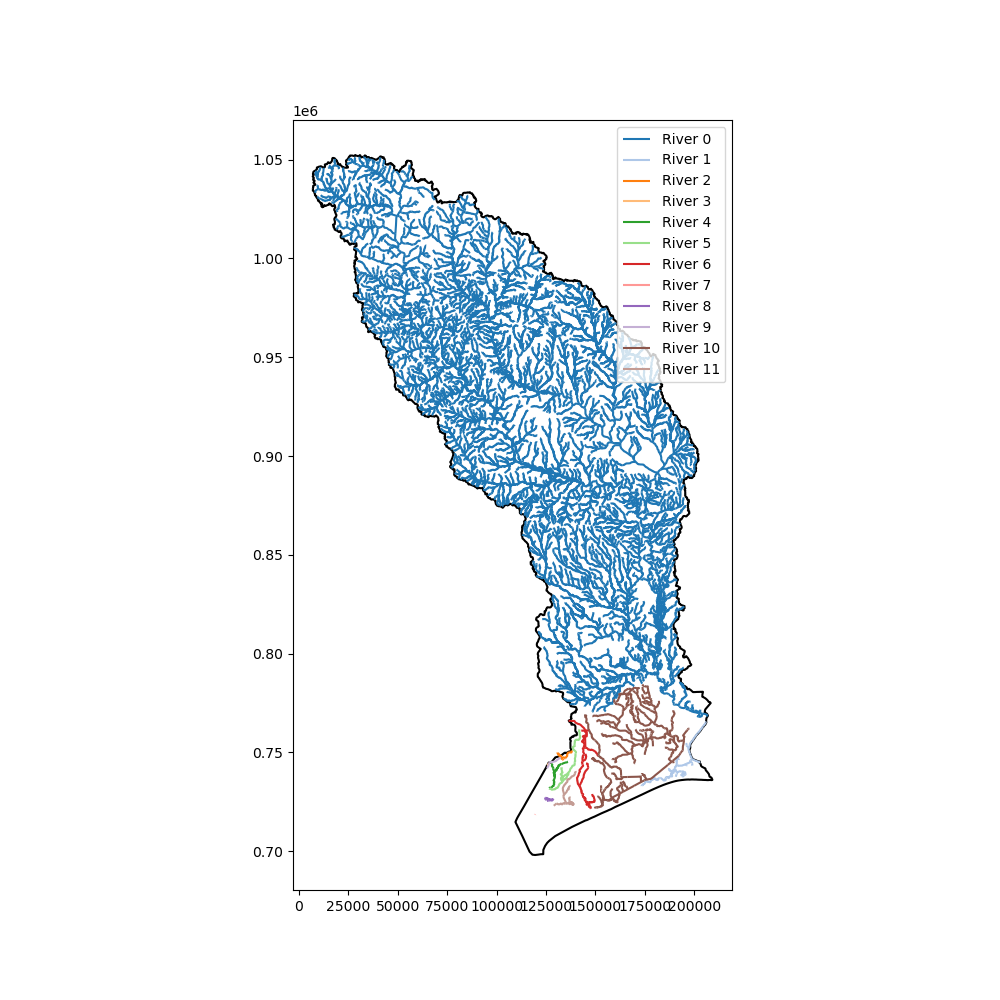

In [21]:
def plot(ws, rivs, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,10))
    
    # plot watershed
    ws.plot(color='k', markersize=5, ax=ax)
    
    # color palette
    colors = plt.cm.tab20.colors
    
    # plot rivers with unique colors
    for i, river in enumerate(rivs):
        river.plot(markersize=1, ax=ax, color=colors[i % 20],label=f"River {i}")
    
    ax.legend()
    return ax

ax = plot(watershed, rivers)
plt.show()

In [22]:
print(len(rivers))

12


In [23]:
for i, r in enumerate(rivers):
    print(f"River {i}: {r['name']}, reaches = {len(r.df)}")

River 0: Neches River, reaches = 5530
River 1:  , reaches = 100
River 2:  , reaches = 5
River 3:  , reaches = 2
River 4: West Fork Double Bayou, reaches = 5
River 5: East Fork Double Bayou, reaches = 8
River 6: Oyster Bayou, reaches = 45
River 7:  , reaches = 1
River 8: Lone Oak Bayou, reaches = 15
River 9: Trinity River, reaches = 5
River 10:  , reaches = 426
River 11:  , reaches = 19


In [24]:
rivers = [r for r in rivers if len(r.df) >= 101]

In [25]:
for i, r in enumerate(rivers):
    print(f"River {i}: {r['name']}, reaches = {len(r.df)}")

River 0: Neches River, reaches = 5530
River 1:  , reaches = 426


In [26]:
# prune

pruned_r0 = watershed_workflow.reduceRivers([rivers[0]],
                                            prune_by_area=prune_by_area,
                                            remove_diversions=True,
                                            remove_braided_divergences=True)[0]

pruned_r0.resetDataFrame()
rivers[0] = pruned_r0

prune_by_area2=10

pruned_r1= watershed_workflow.reduceRivers([rivers[1]],
                                            prune_by_area=prune_by_area2,
                                            remove_diversions=True,
                                            remove_braided_divergences=True)[0]

pruned_r1.resetDataFrame()
rivers[1] = pruned_r1

reduced_reaches = pd.concat([r.df for r in rivers])

2025-11-21 12:51:29,151 - root - INFO: Removing rivers with area < 100
2025-11-21 12:51:29,164 - root - INFO: Removing divergent sections...
2025-11-21 12:51:29,384 - root - INFO:   ... removed 176 divergence tributaries with 307 total reaches.
2025-11-21 12:51:31,534 - root - INFO: ... pruned 4045 of 5223
2025-11-21 12:51:31,606 - root - INFO: Removing rivers with area < 10
2025-11-21 12:51:31,608 - root - INFO: Removing divergent sections...
2025-11-21 12:51:31,639 - root - INFO:   ... removed 33 divergence tributaries with 63 total reaches.
2025-11-21 12:51:31,691 - root - INFO: ... pruned 117 of 363


In [27]:
for i, r in enumerate(rivers):
    print(f"River {i}: {r['name']}, reaches = {len(r.df)}")

River 0: Neches River, reaches = 1178
River 1:  , reaches = 246


<Axes: >

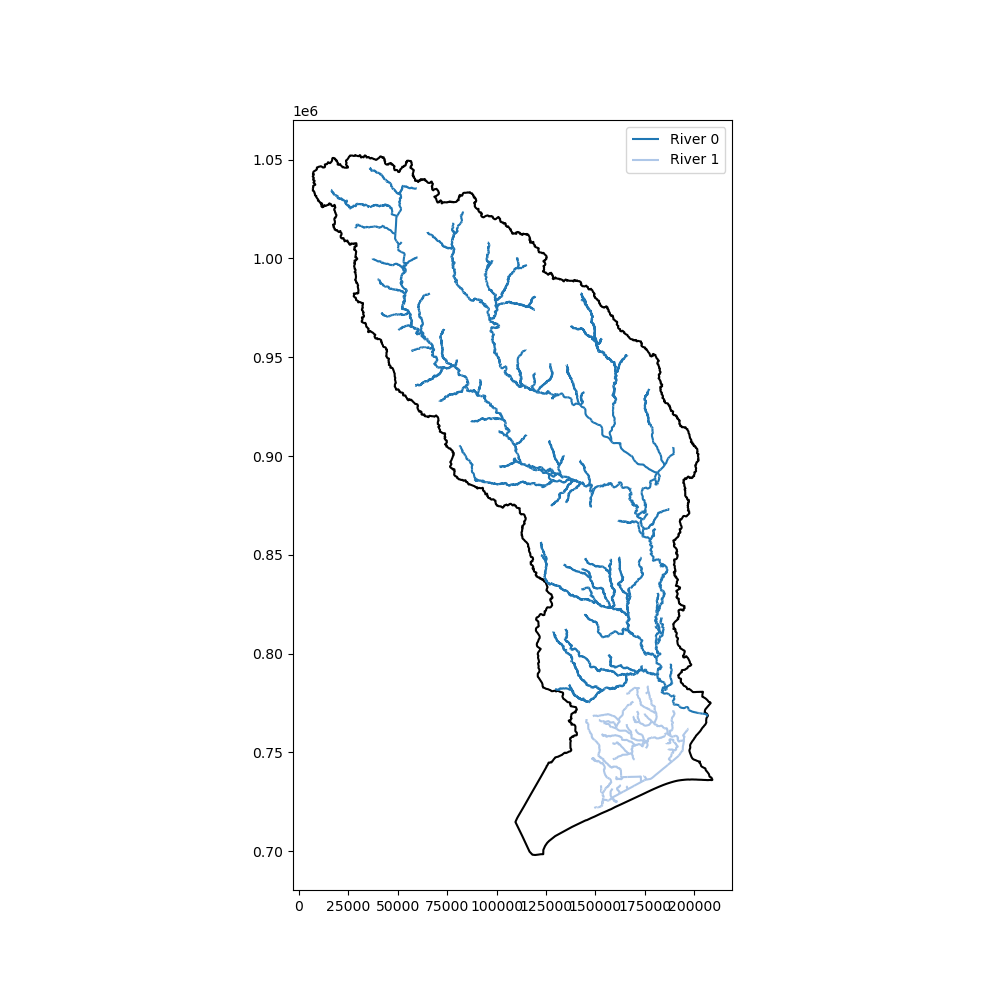

In [28]:
plot(watershed, rivers)

In [29]:
shp_path = "/Users/s2t/research/neches/scripts/outlets_with_subbasins.shp"

# load it as a GeoDataFrame
outlets = gpd.read_file(shp_path)

In [30]:
outlets = outlets.to_crs(watershed_workflow.crs.default_crs)
outlets

,outlet_ID,subbasin,comid,measure,geometry
0,1115825,Neches River,1115825.0,0.000000,POINT (206708.928 768218.485)
1,1114345,"Neches Rv Saltwater Barrier at Beaumont, TX",1114345.0,70.148240,POINT (184815.032 785355.021)
2,1111453,"Neches Rv nr Town Bluff, TX",1111453.0,36.536823,POINT (177645.002 857624.955)
3,1109655,"Neches Rv nr Rockland, TX",1109655.0,68.708029,POINT (152601.284 884938.635)
4,1079041,"Neches Rv nr Diboll, TX",1079041.0,14.809472,POINT (113357.928 895856.277)
5,1077643,"Neches Rv nr Alto, TX",1077643.0,88.308180,POINT (80578.096 943626.353)
6,1152351,"Angelina Rv nr Lufkin, TX",1152351.0,6.487554,POINT (120681.336 932101.895)
7,1150499,"Angelina Rv nr Alto, TX",1150499.0,25.782583,POINT (98937.809 954562.012)
8,4452936,"Neches Rv nr Neches, TX",4452936.0,88.308180,POINT (53003.335 976941.497)
9,1166409,"Village Ck nr Kountze, TX",1166409.0,36.536823,POINT (166350.512 812760.518)


In [31]:
outlets.loc[17, 'comid'] = 1524153

In [32]:
watershed.df

,FID,geometry,ID,name,reach_ID,outlet
0,0,"POLYGON ((18974.998 1021965.049, 18852.987 102...",0,0,1115825,POINT (579625.3302517189 -1316883.0871090333)


In [33]:
outlets

,outlet_ID,subbasin,comid,measure,geometry
0,1115825,Neches River,1115825.0,0.000000,POINT (206708.928 768218.485)
1,1114345,"Neches Rv Saltwater Barrier at Beaumont, TX",1114345.0,70.148240,POINT (184815.032 785355.021)
2,1111453,"Neches Rv nr Town Bluff, TX",1111453.0,36.536823,POINT (177645.002 857624.955)
3,1109655,"Neches Rv nr Rockland, TX",1109655.0,68.708029,POINT (152601.284 884938.635)
4,1079041,"Neches Rv nr Diboll, TX",1079041.0,14.809472,POINT (113357.928 895856.277)
5,1077643,"Neches Rv nr Alto, TX",1077643.0,88.308180,POINT (80578.096 943626.353)
6,1152351,"Angelina Rv nr Lufkin, TX",1152351.0,6.487554,POINT (120681.336 932101.895)
7,1150499,"Angelina Rv nr Alto, TX",1150499.0,25.782583,POINT (98937.809 954562.012)
8,4452936,"Neches Rv nr Neches, TX",4452936.0,88.308180,POINT (53003.335 976941.497)
9,1166409,"Village Ck nr Kountze, TX",1166409.0,36.536823,POINT (166350.512 812760.518)


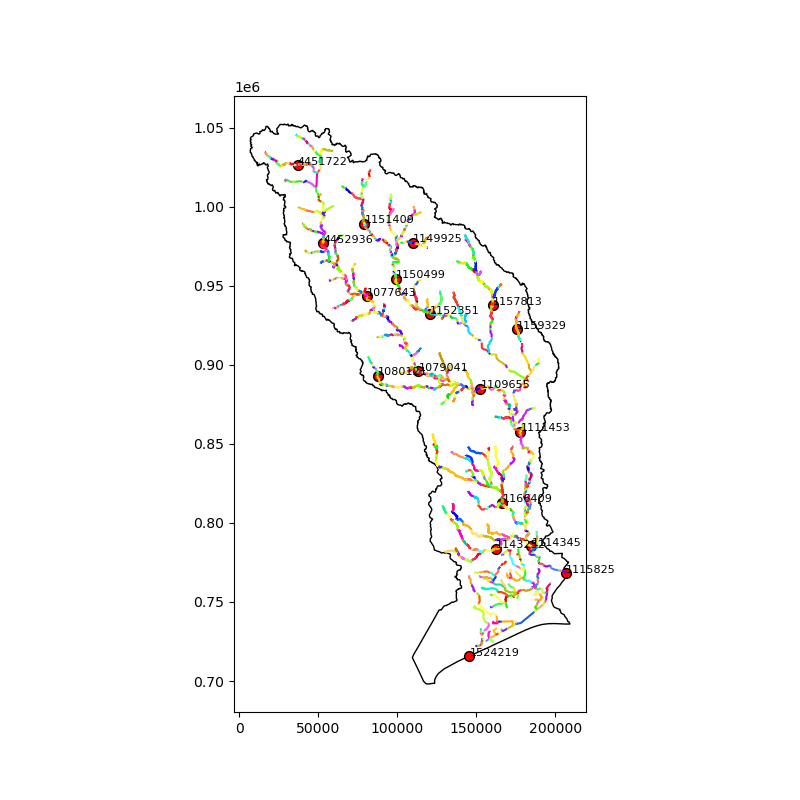

In [34]:
fig, ax = plt.subplots(figsize=(8, 8))
watershed.df.plot(ax=ax, facecolor='none', edgecolor='black')
rivers[0].plot(ax=ax)
rivers[1].plot(ax=ax, linestyle='-')
outlets.plot(ax=ax, color='red', markersize=50, edgecolor='black')

for x, y, label in zip(outlets.geometry.x, outlets.geometry.y,outlets['outlet_ID']):
    ax.text(x + 200, y + 200, label, fontsize=8)

plt.show()

In [35]:
# are all of our gages STILL in our reduced network?
print(sum(outlets['comid'].isin(reduced_reaches['comid'])), ' of ', len(outlets), ' are in the set of REDUCED reaches')

18  of  18  are in the set of REDUCED reaches


In [36]:
# river_df = gpd.GeoDataFrame(pd.concat([r.to_dataframe() for r in rivers]), crs=crs)
# river_df.to_parquet(toOutput('rivers', '01_rivers.parquet'))

In [37]:
# # Convert geometry to WKT text
# river_df['geometry'] = river_df['geometry'].apply(lambda g: g.wkt if g is not None else None)

# # Save as CSV
# river_df.to_csv("/Users/s2t/research/neches/scripts/01_rivers.csv", index=False)


In [38]:
watershed.df.columns


Index(['FID', 'geometry', 'ID', 'name', 'reach_ID', 'outlet'], dtype='object')

In [39]:
# # this generates a zoomable map, showing different reaches and watersheds, 
# # with discrete points.  Problem areas are clickable to get IDs for manual
# # modifications.
# m = watershed.explore(marker=False)
# for river in rivers_orig:
#     m = river.explore(m=m, column=None, color='black', name=river['name']+' raw', marker=False)
# for river in rivers:
#     m = river.explore(m=m)
    
# m = watershed_workflow.makeMap(m)
# m

In [40]:
print(rivers[1].df.columns)

Index(['geometry', 'comid', 'fdate', 'resolution', 'gnis_id', 'reachcode',
       'flowdir', 'wbareacomi', 'ftype', 'fcode',
       ...
       'ID', 'name', 'length', 'stream_order', 'drainage_area_sqkm',
       'catchment', 'hydroseq', 'uphydroseq', 'dnhydroseq', 'divergence'],
      dtype='object', length=145)


In [41]:

node_1 = rivers[1].df.index[rivers[1].df['reachcode'] == '12040202000305'].tolist()[0]


<Axes: >

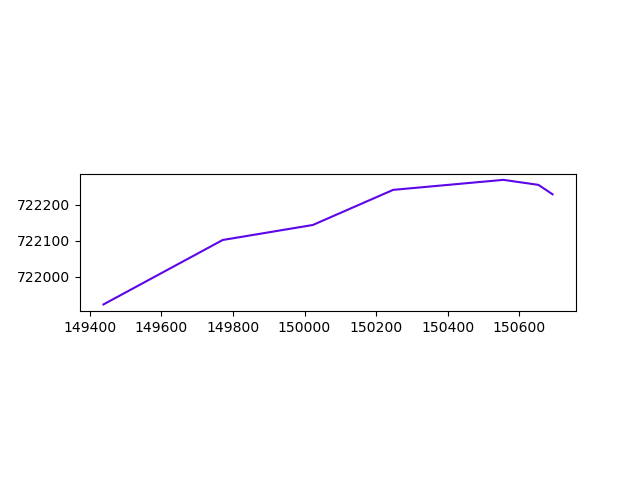

In [42]:
node = rivers[1].getNode(node_1)  
geom = node['geometry']
gdf = gpd.GeoDataFrame({'geometry': [geom]})

gdf.plot()

<Axes: >

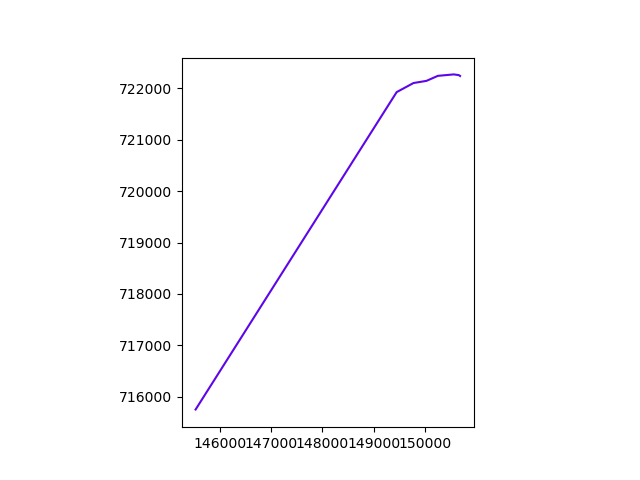

In [43]:
from shapely.geometry import LineString
coords = list(node['geometry'].coords)
coords[-1] = (145522.975, 715734.527)
node['geometry'] = LineString(coords)

# Plot
gpd.GeoDataFrame({'geometry':[node['geometry']]}).plot()

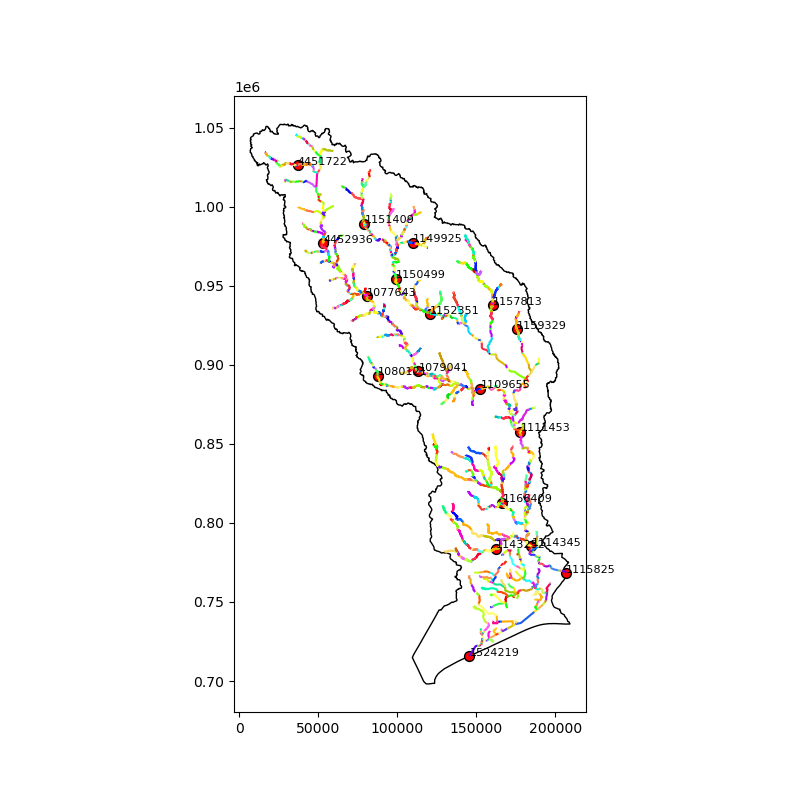

In [44]:
fig, ax = plt.subplots(figsize=(8, 8))
watershed.df.plot(ax=ax, facecolor='none', edgecolor='black')
rivers[0].plot(ax=ax)
rivers[1].plot(ax=ax, linestyle='-')
outlets.plot(ax=ax, color='red', markersize=50, edgecolor='black')

for x, y, label in zip(outlets.geometry.x, outlets.geometry.y,outlets['outlet_ID']):
    ax.text(x + 200, y + 200, label, fontsize=8)

plt.show()

In [45]:
# are all of our gages STILL in our reduced network?
print(sum(outlets['comid'].isin(reduced_reaches['comid'])), ' of ', len(outlets), ' are in the set of REDUCED reaches')

18  of  18  are in the set of REDUCED reaches


In [46]:
rivers[0].isContinuous()

True

In [47]:
rivers[0].makeContinuous()

In [48]:
# simplifying 
watershed_workflow.simplify(watershed, rivers, 
                            reach_segment_target_length=100,
                            huc_segment_target_length=300,
                            river_close_distance=100,
                            river_far_distance=300,
                            snap_triple_junctions_tol=150)
                           

# greatly shrunk the rivers... shrink the dataframe too
for river in rivers:
    river.resetDataFrame()

2025-11-21 12:51:33,196 - root - INFO: 
2025-11-21 12:51:33,197 - root - INFO: Simplifying
2025-11-21 12:51:33,197 - root - INFO: ------------------------------
2025-11-21 12:51:33,198 - root - INFO: EPSG:5070
2025-11-21 12:51:33,199 - root - INFO: Presimplify to remove colinear, coincident points.
2025-11-21 12:51:33,240 - root - INFO: EPSG:5070
2025-11-21 12:51:33,241 - root - INFO: Pruning leaf reaches < 100
2025-11-21 12:51:33,247 - root - INFO:   ...cleaned leaf linestring of length: 50.4669 at centroid (189782.5640598401, 901239.5130804398)
2025-11-21 12:51:33,251 - root - INFO: EPSG:5070
2025-11-21 12:51:33,251 - root - INFO: Merging internal reaches < 100
2025-11-21 12:51:33,259 - root - INFO:   ...cleaned inner linestring of length 49.6733 at centroid (181273.38038815174, 789058.7721055985) with id '1145428'
2025-11-21 12:51:33,265 - root - INFO:   ...cleaned inner linestring of length 68.9466 at centroid (177516.70684229315, 790049.4589364877) with id '1142840'
2025-11-21 12:

GEOSException: IllegalArgumentException: point array must contain 0 or >1 elements


In [ ]:
for river in rivers:
    river.resetDataFrame()

# Now that the river network is set, find the watershed boundary outlets
for river in rivers:
    watershed_workflow.hydrography.findOutletsByCrossings(watershed, river)

In [ ]:
print(len(watershed.df))  
